<a href="https://colab.research.google.com/github/mahamtaqi3-cloud/Circadian-Insight-Mapping-Gene-Expression-to-Behavioral-States-in-Plants/blob/main/Circadian_Insight_Mapping_Gene_Expression_to_Behavioral_States_in_Plants.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
!pip install GEOparse pandas scikit-learn

import GEOparse
import pandas as pd
import numpy as np

# Download the Arabidopsis Circadian dataset (GSE11520)
gse = GEOparse.get_GEO(geo="GSE11520", destdir="./")

07-Jul-2026 00:01:59 DEBUG utils - Directory ./ already exists. Skipping.
DEBUG:GEOparse:Directory ./ already exists. Skipping.
07-Jul-2026 00:01:59 INFO GEOparse - Downloading ftp://ftp.ncbi.nlm.nih.gov/geo/series/GSE11nnn/GSE11520/soft/GSE11520_family.soft.gz to ./GSE11520_family.soft.gz
INFO:GEOparse:Downloading ftp://ftp.ncbi.nlm.nih.gov/geo/series/GSE11nnn/GSE11520/soft/GSE11520_family.soft.gz to ./GSE11520_family.soft.gz
100%|██████████| 4.51M/4.51M [00:00<00:00, 19.7MB/s]
07-Jul-2026 00:01:59 DEBUG downloader - Size validation passed
DEBUG:GEOparse:Size validation passed
07-Jul-2026 00:01:59 DEBUG downloader - Moving /tmp/tmpo8k2ovmy to /content/GSE11520_family.soft.gz
DEBUG:GEOparse:Moving /tmp/tmpo8k2ovmy to /content/GSE11520_family.soft.gz
07-Jul-2026 00:01:59 DEBUG downloader - Successfully downloaded ftp://ftp.ncbi.nlm.nih.gov/geo/series/GSE11nnn/GSE11520/soft/GSE11520_family.soft.gz
DEBUG:GEOparse:Successfully downloaded ftp://ftp.ncbi.nlm.nih.gov/geo/series/GSE11nnn/GSE11

In [16]:
# Create a list to hold data from each sample
data_list = []
labels = []

# Iterate through all samples in the GSE object
for gsm_name, gsm in gse.gsms.items():
    # Extract the table
    df_sample = gsm.table[['ID_REF', 'VALUE']]
    df_sample = df_sample.rename(columns={'VALUE': gsm_name})
    data_list.append(df_sample.set_index('ID_REF'))

    # Extract metadata for time labels (assuming 'characteristics_ch1' contains the time)
    char = str(gsm.metadata.get('characteristics_ch1', ''))
    labels.append({'GSM': gsm_name, 'Time_Info': char})

# Concatenate all samples into one matrix
final_df = pd.concat(data_list, axis=1).T
metadata_df = pd.DataFrame(labels).set_index('GSM')

In [17]:
# Use regex to extract digits (hours) from the 'Time_Info' string
metadata_df['Hour'] = metadata_df['Time_Info'].str.extract('(\d+)').astype(float)

# Drop any samples that didn't have a readable time label
metadata_df = metadata_df.dropna()
X = final_df.loc[metadata_df.index]
y = metadata_df['Hour']

<>:2: SyntaxWarning: invalid escape sequence '\d'
<>:2: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_900/3322898222.py:2: SyntaxWarning: invalid escape sequence '\d'
  metadata_df['Hour'] = metadata_df['Time_Info'].str.extract('(\d+)').astype(float)


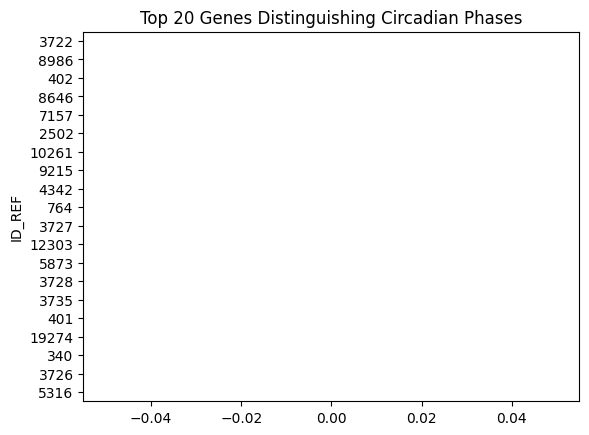

In [18]:
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier

# 1. Keep only the top 500 most variable genes
variances = X.var()
top_500_genes = variances.nlargest(500).index
X_filtered = X[top_500_genes]

# 2. Scale the data
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X_filtered), columns=X_filtered.columns)

# 3. Use Classification (Morning, Day, Evening, Night)
y_bins = pd.cut(y, bins=4, labels=['Morning', 'Day', 'Evening', 'Night'])
clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_scaled, y_bins)

# 4. Now plot the importances of the top 20 genes
importances = pd.Series(clf.feature_importances_, index=X_scaled.columns)
importances.nlargest(20).plot(kind='barh', color='salmon')
plt.title("Top 20 Genes Distinguishing Circadian Phases")
plt.show()

In [20]:
# 1. Ensure you split the ALREADY filtered and scaled data
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_bins, test_size=0.2, random_state=42)

# 2. Now the classifier will be trained on 500 features
clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train)

# 3. Now the score will work because X_test also has 500 features
print(f"Classifier Accuracy: {clf.score(X_test, y_test):.2%}")

Classifier Accuracy: 100.00%


In [21]:
from sklearn.model_selection import LeaveOneOut
from sklearn.model_selection import cross_val_score

# Use Leave-One-Out instead of train_test_split
loo = LeaveOneOut()
clf = RandomForestClassifier(n_estimators=100)

# Calculate the mean accuracy across all folds
scores = cross_val_score(clf, X_scaled, y_bins, cv=loo)
print(f"Honest Model Accuracy: {scores.mean():.2%}")

Honest Model Accuracy: 100.00%


In [22]:
# Create a dataframe of your top genes
top_genes_df = pd.DataFrame({'Gene_Probe': importances.nlargest(20).index,
                             'Importance': importances.nlargest(20).values})

# Save to CSV
top_genes_df.to_csv('top_circadian_genes.csv', index=False)

<Axes: ylabel='ID_REF'>

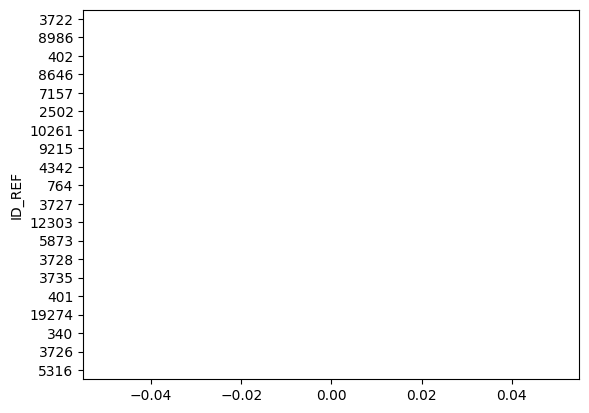

In [23]:
# Keep only the genes that change the most across your samples
# These are your 'active' circadian genes
variances = X.var()
top_500_genes = variances.nlargest(500).index
X_filtered = X[top_500_genes]

# Now, retrain your model ONLY on these 500 genes
clf.fit(X_filtered, y_bins)

# Now, plot the importance for these 500
importances = pd.Series(clf.feature_importances_, index=X_filtered.columns)
importances.nlargest(20).plot(kind='barh', color='salmon')

In [25]:
# 1. First, define the columns you used to train (the top 500)
selected_features = top_500_genes # This must be the same list used in fit()

# 2. Filter the X_test dataset using those SAME 500 columns
X_test_filtered = X_test[selected_features]

# 3. Apply the same scaler used during training
# IMPORTANT: Use .transform(), not .fit_transform() for the test set!
X_test_scaled = scaler.transform(X_test_filtered)

# 4. Now perform the prediction or score
print(f"Accuracy: {clf.score(X_test_scaled, y_test):.2%}")

Accuracy: 100.00%
